<a href="https://colab.research.google.com/github/WPozz/Calories-and-Wellbeing/blob/main/Gruppo11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 11: Clinical Text Classification

In [4]:
# Basic libraries:

import os
import time
import pandas as pd
import numpy as np
from tqdm import tqdm
import string
import re
import math

# Plot libraries:
import matplotlib.pyplot as plt
import seaborn as sns


# Sklearn:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.manifold import TSNE

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE

# Data agumentation libraries:
!pip install nlpaug
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw

# Colab:
from google.colab import files
from google.colab import drive

# Torch and Transformers:

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW, get_linear_schedule_with_warmup


# First way to upload the data (Dowload from Kaggle):
#import kagglehub
#path = kagglehub.dataset_download("shoubhikchakra/mtsamples-dataset")


print('Libraries succesfully imported')


RuntimeError: Only a single TORCH_LIBRARY can be used to register the namespace prims; please put all of your definitions in a single TORCH_LIBRARY block.  If you were trying to specify implementations, consider using TORCH_LIBRARY_IMPL (which can be duplicated).  If you really intended to define operators for a single namespace in a distributed way, you can use TORCH_LIBRARY_FRAGMENT to explicitly indicate this.  Previous registration of TORCH_LIBRARY was registered at /usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py:37; latest registration was registered at /usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py:37

In [ ]:
# Data loading:

# drive.mount('/content/gdrive')
# %cd '/content/gdrive/My Drive/DL'

try:
    raw_data = pd.read_csv('mtsamples.csv')
    print("Data succesfully loaded")
except FileNotFoundError:
    print(f"Error: data file not found.")

# Print basic info
print("Initial Data Info:")
print(raw_data.columns)
raw_data.head(5)

**Pre-pre-processing plot functions**

Here we define the functions with the plots for the EDA. The major plots are:
1. Label (class) distribution
2. Top k N-grams in the dataset
3. Top k N-grams for each label  

In [ ]:

# Barplot with label:

def plot_label_distribution(raw_data, column, title, filename):

    """
    Helper function to create and save a bar plot of a column's distribution.

    Inputs:
            raw_data = (list) data to analyze
            column   = (string) column to analyze
            title    = (string) title of the plot
            filename = (string)
    Output:
            none (just the plot)

    """
    print(f"Generating plot: {title}...")
    plt.figure(figsize=(10, 12))

    # Plotting
    sns.countplot(
        y=column,
        data=raw_data,
        order=raw_data[column].value_counts().index,
        palette='viridis'   # we can select another palette
    )

    # Formatting
    plt.title(title, fontsize=16)
    plt.xlabel('Number of Samples', fontsize=12)
    plt.ylabel('Medical Specialty', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show


# N-grams in the whole dataset:

def plot_top_ngrams(text_data,n,top_k,title):
    """
    This function creates and saves a bar plot
    for the top N-grams :

    Inputs:
            text_data = the actual data
            n = (scalar) number of grams to consider
            top_k = (scalar) how many elements to show
            title = (string) title of the plot
    Output:
            None (just the plot)

    """
    print(f"Generating plot: {title}...")


    # We remove the "stop words" and look for n-grams with (n x n) dimension

    vec = CountVectorizer(
         stop_words='english',
         ngram_range=(n, n)
     )


    X = vec.fit_transform(text_data)

    # We sum the counts for each n-gram across
    counts = X.sum(axis=0)

    # Get the names of the features, the n-grams and the counts
    words = vec.get_feature_names_out()

    # Create a df with n-grams and their counts
    counts_df = pd.DataFrame({
    'ngram': words,
    'count': np.asarray(counts).flatten() # Convert the row of the matrix into a dense array
     })

    # We only keep the top_k
    top_counts_df = counts_df.sort_values(by='count', ascending=False).head(top_k)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(
         x='count',
         y='ngram',
        data=top_counts_df,
        palette='viridis_r' # reversed palette
         )
    plt.title(title, fontsize=16)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('N-Gram', fontsize=12)
    plt.tight_layout()
    plt.show()


# Sentence lenght:

def plot_lenghts(text_data):
    """
    This function retrives and plots the average lenght of the sentences.

    Inputs:
            text_data = (list) data to analyze

    Outputs:
            None (just the plot)

    """
    sentence_lengths = [len(sentence.split()) for sentence in text_data]

    plt.figure(figsize=(10, 6))
    sns.histplot(sentence_lengths, bins='auto', kde=True, color='green', shrink= 1)
    plt.title('Distribution of Sentence Lengths')
    plt.xlabel('Sentence Length (words)')
    plt.ylabel('Frequency')
    plt.show()

    print(f"Average sentence length: {np.mean(sentence_lengths):.2f} words")
    print(f"Median sentence length: {np.median(sentence_lengths)} words")
    print(f"Max sentence length: {np.max(sentence_lengths)} words")
    print(f"Min sentence length: {np.min(sentence_lengths)} words")



# N-grams per class

def plot_ngrams_per_class(data, text_col, class_col, top_k=15, n=1, num_classes=6):
    """
    Plots a grid of bar charts showing the top N-grams for the
    top N most frequent classes.

    Inputs:
            data = (dataframe) data to analyze
            text_col = (string) name of the text column
            class_col = (string) name of the class column
            top_k =  (scalar) how many grams to show
            n = (scalar) number of grams to consider
            num_classes = (scalar) Number of classes to show

    Outputs:
            None (just the plots)
    """
    print(f"Generating plot: Top {n}-grams per Class (Top {num_classes})...")
    data_clean = data.dropna(subset=[text_col, class_col])
    top_classes = data_clean[class_col].value_counts().nlargest(num_classes).index

    ncols = 3
    nrows = math.ceil(num_classes / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 7))
    axes = axes.flatten() # Flatten the grid for easy iteration

    for i, specialty in enumerate(top_classes):
        ax = axes[i]
        specialty_text = data_clean[data_clean[class_col] == specialty][text_col]

        try:
            vec = CountVectorizer(stop_words='english', ngram_range=(n, n))
            X = vec.fit_transform(specialty_text)
            counts = X.sum(axis=0)      # Compiler gives error but works anyway
            words = vec.get_feature_names_out()

            counts_df = pd.DataFrame({'ngram': words, 'count': np.asarray(counts).flatten()})
            top_counts_df = counts_df.sort_values(by='count', ascending=False).head(top_k)

            sns.barplot(x='count', y='ngram', data=top_counts_df, ax=ax, palette='viridis_r', hue='ngram', legend=False)
            ax.set_title(f"Top {n}-grams for '{specialty}'", fontsize=14)
            ax.set_xlabel('Frequency')
            ax.set_ylabel(f'{n}-gram')
        except ValueError:
            # This can happen if a specialty has no text after stopword removal
            ax.set_title(f"Could not generate {n}-grams for '{specialty}'", fontsize=14)
            ax.text(0.5, 0.5, 'Not enough data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'top_{n}grams_per_class.png')
    print(f"Saved plot to top_{n}grams_per_class.png")
    plt.close()




# Let's do sentence lenght per label:
# Mi rendo conto che la function è brutta ma era la cosa più pratica da fare in 2 min.

def plot_lenghts_per_class(data, text_col, class_col, num_classes=6):
  """
    Plots sentence lenghts per class.

    Inputs:
            data = (dataframe) data to analyze
            text_col = (string) name of the text column
            class_col = (string) name of the class column
            num_classes = (scalar) Number of classes to show

    Outputs:
            None (just the plots)

  """
  print(f"Generating plot: Sentence Lenghts per Class (Top {num_classes})...")
  data_clean = data.dropna(subset=[text_col, class_col])
  top_classes = data_clean[class_col].value_counts().nlargest(num_classes).index
  ncols = 3
  nrows = math.ceil(num_classes / ncols)
  fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 7))
  axes = axes.flatten() # Flatten the grid for easy iteration
  for i, specialty in enumerate(top_classes):
    ax = axes[i]
    specialty_text = data_clean[data_clean[class_col] == specialty][text_col]
    sentence_lengths = [len(sentence.split()) for sentence in specialty_text]
    sns.histplot(sentence_lengths, bins='auto', kde=True, color='green', shrink= 1, ax=ax)
    ax.set_title(f"Sentence Lengths for '{specialty}'", fontsize=14)
    ax.set_xlabel('Sentence Length (words)')
    ax.set_ylabel('Frequency')


    all_classes  = data_clean[class_col].value_counts().nlargest(40).index
  # Let's print a list with the average length per class for every class:
  for specialty in all_classes:

    specialty_text = data_clean[data_clean[class_col] == specialty][text_col]
    sentence_lengths = [len(sentence.split()) for sentence in specialty_text]
    print(f"Average sentence length for '{specialty}': {np.mean(sentence_lengths):.2f} words")


    # Hide any unused subplots
  for j in range(i + 1, len(axes)):
    axes[j].axis('off')
  plt.tight_layout()
  plt.savefig(f'sentence_lenghts_per_class.png')
  print(f"Saved plot to sentence_lenghts_per_class.png")
  plt.show()
  plt.close()


# Other plots ideas:
# Wordclouds for each class






In [ ]:


try:

    plot_label_distribution(raw_data, 'medical_specialty', 'Medical Specialty Distribution', 'medical_specialty_distribution.png')

    text_data = raw_data.dropna(subset=['transcription'])['transcription'] # Remove Nan to avoid errors

    plot_lenghts(text_data)

    # N-grams general

    # Plot for N = 1
    plot_top_ngrams(text_data,n=1,top_k=20,title='Top 20 Most Frequently Occuring Unigrams')

    # Plot for N = 2
    plot_top_ngrams(text_data,n=2,top_k=20,title='Top 20 Most Frequently Occuring Bigrams')

    # Plot for N = 3
    plot_top_ngrams(text_data,n=3,top_k=20,title='Top 20 Most Frequently Occuring Trigrams')

    # N-grams per class:

    # Plot for N = 1
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=1, num_classes=6)

    # Plot for N = 2
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=2, num_classes=6)

    # Plot for N = 3
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=3, num_classes=6)

    # Lenght per class:

    plot_lenghts_per_class(raw_data, 'transcription', 'medical_specialty', num_classes=6)
except KeyError:
    print('"transcription" column not found.')
except Exception as e:
    print(f"An error occurred: {e}")



**Pre-processing**

Looking at the initial plots, we see that the dataset has **two major problems**:
1. There are some very small but meaningfull classes (Allergy / Immunology - Hospice) with less than 20 samples.
2. There are some noisy and vague noisy classes (Consult - History and Phy SOAP / Chart).

This is a classic "**garbage in - garbage out**" problem where there is the risk of feeding the model with noisy and unbalanced data. This can result in low interpretability and poor performances.  

The idea is to pre-process the data by performing an aggressive **data cleaning** and **data augmentation**. The data cleaning function should:  

1. Drop NaNs and 'Unnamed: 0' column.
2. Merge similar classes ('Neurology' and 'Neurosurgery').
3. Remove a specific list of noisy/document-type labels (letters, office notes, ecc.).
4. Filter out any remaining classes with < min_samples.

The data augmentation will be performed using the "**back translation**" technique. We'll translate the samples in different languages (German, Italian and Russian) to augment the samples without altering the original meaning.

In [ ]:

def pre_processing_data(data, min_samples=50):
    """
    Performs aggressive cleaning of the 'medical_specialty' column
    based on the Model 3 strategy:
    1. Drops NaNs and 'Unnamed: 0' column.
    2. Merges similar classes
    3. Removes a specific list of noisy/document-type labels.
    4. Filters out any remaining classes with < min_samples.

    Inputs:
            "data" = (DataFrame) The raw data to clean.
            "min_samples" = (int) Threshold for the minimum samples per class.

    Output:
            (DataFrame) The pre-processed, cleaned and filtered data.
    """
    print("--- Starting Data Cleaning ---")
    print(f"Original dataset shape: {data.shape}")

    # Make a copy to avoid SettingWithCopyWarning
    data = data.copy()

    # 1. Initial cleanup
    if 'Unnamed: 0' in data.columns:
        data = data.drop(columns=['Unnamed: 0'])

    data['medical_specialty'] = data['medical_specialty'].str.strip()
    data = data.dropna(subset=['transcription', 'medical_specialty'])
    print(f"Shape after dropping NaNs: {data.shape}")

    # 2. Merge similar specialties (we should decide which one)
    merge_map = {
        'Bariatrics': 'Surgery',
        'Cosmetic / Plastic Surgery': 'Surgery',
        'Neurosurgery': 'Neurology / Neurosurgery',
        'Neurology': 'Neurology / Neurosurgery' # Map base class too
    }

    data['medical_specialty'] = data['medical_specialty'].replace(merge_map)
    print("Completed merging 'Bariatrics'/'Cosmetic' into 'Surgery' and 'Neurosurgery' into 'Neurology / Neurosurgery'.")

    # 3. Define and remove "noisy" labels (document types, not specialties)
    noisy_labels = [
        'Consult - History and Phy.',
        'SOAP / Chart / Progress Notes',
        'Discharge Summary',
        'Emergency Room Reports',
        'General Medicine',
        'Radiology',            # Debatable
        'Office Notes',
        'Letters',
        'IME-QME-Work Comp etc.',
        'Lab Medicine - Pathology',
        'Autopsy'               # Debatable
    ]


    noisy_count = data['medical_specialty'].isin(noisy_labels).sum()
    print(f"Found {noisy_count} samples with noisy labels to remove.")

    data = data[~data['medical_specialty'].isin(noisy_labels)]
    print(f"Shape after removing noisy labels: {data.shape}")

    # 4. Handle class imbalance by removing specialties with < min_samples
    specialty_counts = data['medical_specialty'].value_counts()
    specialties_to_keep = specialty_counts[specialty_counts >= min_samples].index

    original_classes = data['medical_specialty'].nunique()
    print(f"Classes before min_sample filter: {original_classes}")

    data = data[data['medical_specialty'].isin(specialties_to_keep)]
    print(f"Shape after removing classes with < {min_samples} samples: {data.shape}")

    final_classes = data['medical_specialty'].nunique()
    print(f"--- Cleaning Complete ---")
    print(f"Final number of classes: {final_classes}")

    return data.reset_index(drop=True)


In [ ]:

try:
     clean_data = pre_processing_data(raw_data, min_samples=50)
     print('Data pre-processing completed successfully.')
except KeyError:
    print('"transcription" or "medical_specialty" column not found.')
except Exception as e:
    print(f"An error occurred: {e}")

print("\n--- New Class Distribution (After Pre-processing) ---")
print(clean_data['medical_specialty'].value_counts())
print('Mean number of samples per class after cleaning:', clean_data['medical_specialty'].value_counts().mean())
print('Median number of samples per class after cleaning:', clean_data['medical_specialty'].value_counts().median())


--- Starting Data Cleaning ---
Original dataset shape: (4999, 6)
Shape after dropping NaNs: (4966, 5)
Completed merging 'Bariatrics'/'Cosmetic' into 'Surgery' and 'Neurosurgery' into 'Neurology / Neurosurgery'.
Found 1502 samples with noisy labels to remove.
Shape after removing noisy labels: (3464, 5)
Classes before min_sample filter: 26
Shape after removing classes with < 50 samples: (3245, 5)
--- Cleaning Complete ---
Final number of classes: 14
Data pre-processing completed successfully.

--- New Class Distribution (After Pre-processing) ---
medical_specialty
Surgery                       1133
Cardiovascular / Pulmonary     371
Orthopedic                     355
Neurology / Neurosurgery       317
Gastroenterology               224
Urology                        156
Obstetrics / Gynecology        155
ENT - Otolaryngology            96
Hematology - Oncology           90
Ophthalmology                   83
Nephrology                      81
Pediatrics - Neonatal           70
Pain Manag

# **Pre-Processing Results:**

The pre-processing left us with 14 classes (labels) to deal with. The dataset is still unbalanced but we managed to remove most of the noisiy labels along with classes with too few samples. Before performing the back translation we plot the results of the pre-procesing below.


Note (W): *We should split the data into test-validation-training before the second EDA as we're only interested in the training set (the others won't be touched by the data augmentation). We can also perform data partitioning after the second EDA but this could result in some "peeking" of the data.*

Here we show the EDA after the pre-processing.

Generating plot: Medical Specialty Distribution...


/tmp/ipython-input-3301588043.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


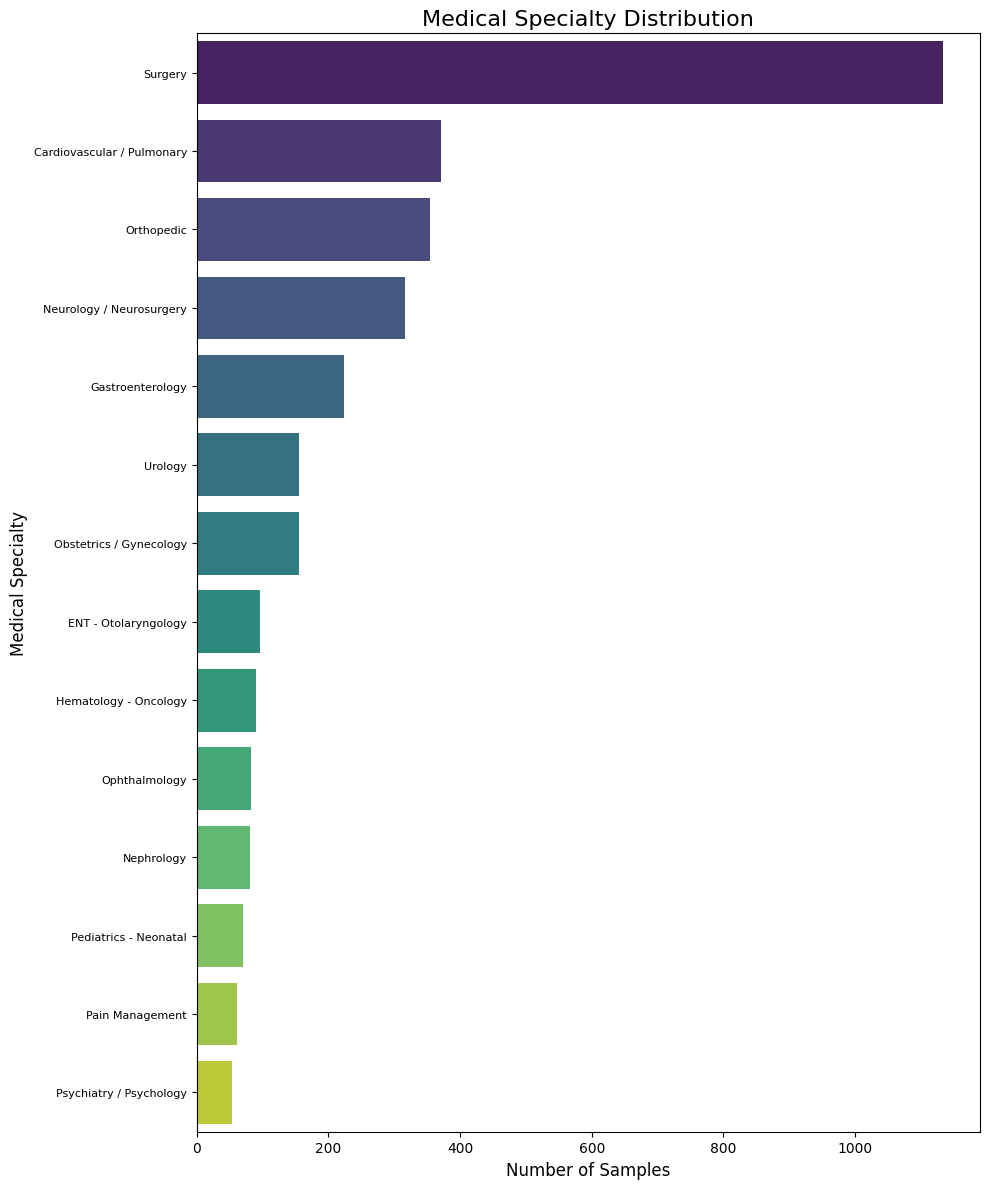

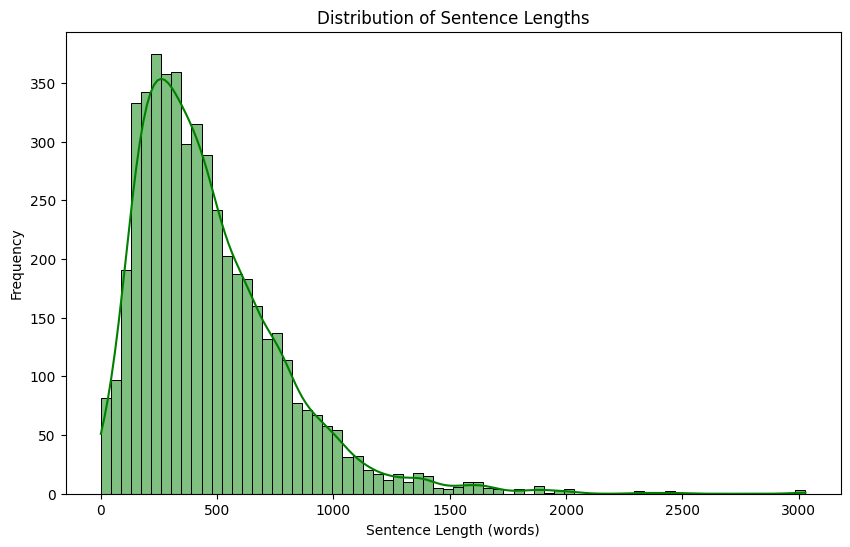

Average sentence length: 465.45 words
Median sentence length: 398.0 words
Max sentence length: 3029 words
Min sentence length: 1 words


In [ ]:
plot_label_distribution(clean_data, 'medical_specialty', 'Medical Specialty Distribution', 'medical_specialty_distribution.png')

text_data = raw_data.dropna(subset=['transcription'])['transcription'] # Remove Nan to avoid errors

plot_lenghts(text_data)

# **Data Partitioning:**

We split the data into three sets: Training, Validation and Test. We can change the proportion but i think that 65%-20%-15% can be a good start.

In [ ]:


def data_partition(data, label_col, train_size=0.65, val_size=0.15, test_size=0.20, random_state=15):
    """
    We split the data into Train, Validation and Test keeping the dataframe format.

    Inputs:
            data = (DataFrame) data to partition
            label_col = (string) name of the label column
            train_size = (float) proportion of the data to use for training
            val_size = (float) proportion of the data to use for validation
            test_size = (float) proportion of the data to use for testing
            random_state = (int) seed for reproducibility

    Outputs:
            train_df = (DataFrame) training set
            val_df = (DataFrame) validation set
            test_df = (DataFrame) testing set

    """
    print("--- Starting Data Partitioning ---")
    print("")

    # First split: Train vs (Validation + Test)

    train_df, temp_df = train_test_split(data,test_size=(val_size + test_size),stratify=data[label_col],random_state=random_state)

    # Second split: Validation vs Test

    relative_test_size = test_size / (val_size + test_size)

    val_df, test_df = train_test_split(temp_df,test_size=relative_test_size,stratify=temp_df[label_col],random_state=random_state)

    # Reset index to avoid further problmes
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"Train DF shape: {train_df.shape}")
    print(f"Val DF shape:   {val_df.shape}")
    print(f"Test DF shape:  {test_df.shape}")

    # We add a small barplot to show the proportions:
    # Create a summary dataframe for plotting
    split_counts_data = {'Split': ['Train', 'Validation', 'Test'],'Count': [len(train_df), len(val_df), len(test_df)]}
    split_counts_df = pd.DataFrame(split_counts_data)

    print("")

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Split', y='Count', data=split_counts_df, palette='muted', hue='Split', legend='auto')
    plt.title('Distribution of Data Across Splits', fontsize=16)
    plt.xlabel('Split', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.show()

    print("")
    print("--- Data Partitioning Complete ---")


    return train_df, val_df, test_df


--- Starting Data Partitioning ---

Train DF shape: (2109, 5)
Val DF shape:   (486, 5)
Test DF shape:  (650, 5)



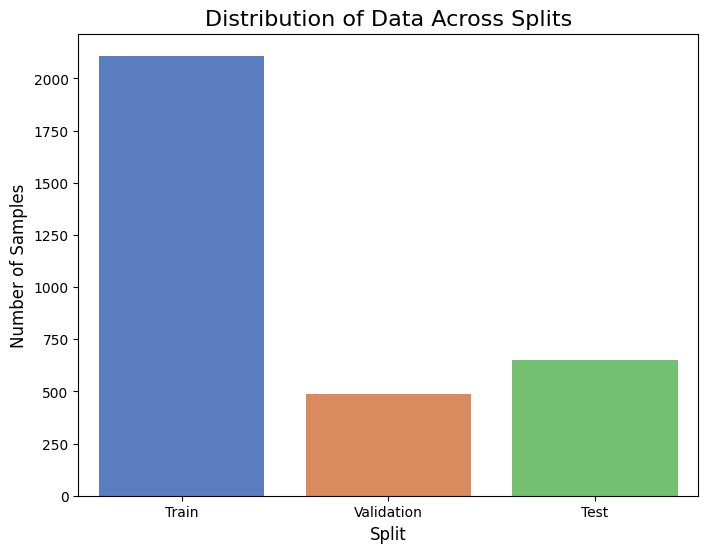


--- Data Partitioning Complete ---
Training set shape:

medical_specialty
Surgery                       736
Cardiovascular / Pulmonary    241
Orthopedic                    231
Neurology / Neurosurgery      206
Gastroenterology              146
Obstetrics / Gynecology       101
Urology                       101
ENT - Otolaryngology           62
Hematology - Oncology          58
Ophthalmology                  54
Nephrology                     53
Pediatrics - Neonatal          46
Pain Management                40
Psychiatry / Psychology        34
Name: count, dtype: int64

Validation set shape:

medical_specialty
Surgery                       170
Cardiovascular / Pulmonary     56
Orthopedic                     53
Neurology / Neurosurgery       47
Gastroenterology               33
Urology                        24
Obstetrics / Gynecology        23
ENT - Otolaryngology           15
Hematology - Oncology          14
Ophthalmology                  12
Nephrology                     12
Pediatr

In [ ]:
train_df, val_df, test_df = data_partition(clean_data, 'medical_specialty')

# We can print the number of samples for each class:

print('Training set shape:')
print('')
print(train_df['medical_specialty'].value_counts())
print('')
print('Validation set shape:')
print('')
print(val_df['medical_specialty'].value_counts())
print('')
print('Test set shape:')
print('')
print(test_df['medical_specialty'].value_counts())

# Questi print sono tanto aberranti quanto funzionanti...

# **Back Translation:**

Here we define the function for the back translation. Important: To avoid **data leakage** the test/train split must be performed before the back translation. We should augment only the training set.

Back Tranlation aletrnatives:

- Random Swap: Randomly choose two words in the sentence and swap their positions. Do this n times. (fast n easy)

- Random Insertion: Find a random synonym of a random word in the sentence that is not a stop word. Insert that synonym into a random position in the sentence. Do this n times. (fast n easy)

- Shuffle Sentences Transform: In this transformation, if the given text sample contains multiple sentences these sentences are shuffled to create a new sample. (Albumentation library)

Note: I like the Helsinky models (proposed from Luca) better as they're faster and smoother than meta (facebook) models. I thinks we should use them.

In [ ]:
def data_augmentation_dual_back_translation(df, text_col, label_col, augmentation_ratio=1.0, max_samples_limit=300):
    """
    Performs Back Translation using both intermediate languages (German and Italian)
    to increase variance. The number of samples generated is proportional to the
    original class size to avoid excessive synthetic data. If max_samples_limit is set,
    it caps the generation so that (original + new) <= limit.

    Inputs:
            df (DataFrame): Input training dataframe.
            text_col (str): Name of the text column.
            label_col (str): Name of the label column.
            augmentation_ratio (float): How many new samples to generate per original sample.
                                        1.0 = double the data (1 original + 1 fake).
                                        2.0 = triple the data (1 original + 2 fake).
                                        Keep <= 2.0 to ensure fake data is not > 2/3 of total.
            max_samples_limit (int): Optional cap. If a class already has this many samples,
                                     it won't be augmented.

    Output:
            final_df (DataFrame): The dataframe with original + augmented data.
    """

    print(f"\n--- Starting Dual-Language Back Translation (German & Italian) ---")

    # Check for GPU or CPU:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    if device == 'cpu':
        print("WARNING: Running on CPU will be extremely slow.")

    # Initialize both models
    print("Loading translation models...")

    # German Pair
    aug_de = naw.BackTranslationAug(
        from_model_name='Helsinki-NLP/opus-mt-en-de',
        to_model_name='Helsinki-NLP/opus-mt-de-en',
        device=device,
        batch_size=32, # Increased batch size for speed (maybe we can push to 32)
        max_length=300
    )

    # Italian Pair
    aug_it = naw.BackTranslationAug(
        from_model_name='Helsinki-NLP/opus-mt-en-it',
        to_model_name='Helsinki-NLP/opus-mt-it-en',
        device=device,
        batch_size=32,
        max_length=300
    )

    class_counts = df[label_col].value_counts()
    new_rows = []


    def get_needed_samples(current_count, ratio, limit):
        """
        Calculates the exact number of new samples to generate for a class.
        It compares the augmentation target against the hard limit to ensure
        the final count never exceeds 'max_samples_limit'.

        Inputs:
                current_count (int) = Current number of samples for the specific class.
                ratio (float)       = The augmentation ratio (e.g., 1.0 = double the data).
                limit (int)         = The maximum allowed total samples (cap).

        Output:
                int = The number of samples to generate (the minimum between
                      the ratio-target and the remaining space).
        """
        # Calculate target based on ratio
        target_increase = int(current_count * ratio)

        # If no limit exists, return the ratio-based target
        if not limit:
            return target_increase

        # If limit exists, calculate space remaining
        space_remaining = limit - current_count

        # If class is already larger than limit, we need 0
        if space_remaining <= 0:
            return 0

        # Return the smaller of the two: (Ratio Target vs Space Remaining)
        return min(target_increase, space_remaining)

    # 2. Total sample estiamte:
    total_new_samples = 0
    for label, count in class_counts.items():
        total_new_samples += get_needed_samples(count, augmentation_ratio, max_samples_limit)

    print(f"\nTotal samples to generate: {total_new_samples}")

    if total_new_samples == 0:
        print("No samples needed based on current limits/ratios.")
        return df

    # Warning checks
    if augmentation_ratio >= 2:
        print('--- Warning! ---')
        print('Ratio is high (>2.0)')
        print('Be aware that more than 2/3 of the data will be synthetic.')
        print('--- Warning! ---')

    # Time Estimate: around 4 seconds per sample (conservative estimate)
    est_minutes = (total_new_samples * 4) / 60
    print(f"Estimated runtime: ~{est_minutes:.1f} minutes...")
    if est_minutes > 60:
        print(f"Estimated runtime: ~{est_minutes / 60:.1f} hours...")
    print("-" * 60)

    # Loop:
    for label, count in class_counts.items():

        # Calculate needed samples:
        n_total_needed = get_needed_samples(count, augmentation_ratio, max_samples_limit)

        # Skip if nothing to generate
        if n_total_needed <= 0:
            print(f"Class '{label}' already has {count} samples. Skipping...")
            continue

        # Split evenly between German and Italian
        n_german = math.ceil(n_total_needed / 2)
        n_italian = n_total_needed - n_german

        samples = df[df[label_col] == label][text_col].tolist()

        print(f"Class '{label}': Original={count} | Generating {n_german} (DE) + {n_italian} (IT) | Final Class Size will be: {count + n_total_needed}")


        def generate_batch(augmenter, target_n, source_texts):
            """
            Executes the back-translation loop for a specific language model.
            It handles text truncation to avoid model errors and updates a
            progress bar for real-time feedback.

            Inputs:
                    augmenter (object)  = The loaded nlpaug model (German or Italian).
                    target_n (int)      = The specific target number of samples to generate.
                    source_texts (list) = List of original text strings to use as source.

            Output:
                    generated_batch (list) = A list of dictionaries containing the
                                             new augmented text and label.
            """
            generated_batch = []
            gen_count = 0

            # Loading bar creation:
            with tqdm(total=target_n, leave=False, desc=f"Gen for {label}") as pbar:
                while gen_count < target_n:
                    for text in source_texts:
                        if gen_count >= target_n:
                            break

                        # Pre-check text length
                        if not isinstance(text, str) or len(text) < 10:
                            continue

                        # Truncate to fit model max_length roughly (very roughly)
                        proc_text = text[:1000] if len(text) > 1000 else text

                        try:
                            # Augment
                            res = augmenter.augment(proc_text)
                            aug_text = res[0] if isinstance(res, list) else res

                            generated_batch.append({text_col: aug_text, label_col: label})
                            gen_count += 1
                            pbar.update(1)
                        except Exception:
                            continue
            return generated_batch

        #  German samples
        if n_german > 0:
            new_rows.extend(generate_batch(aug_de, n_german, samples))

        #  Italian samples
        if n_italian > 0:
            new_rows.extend(generate_batch(aug_it, n_italian, samples))

    # 4. Final part:
    if len(new_rows) > 0:
        aug_df = pd.DataFrame(new_rows)
        # Concatenate and Shuffle
        final_df = pd.concat([df, aug_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

        print(f"\n--- Augmentation Complete ---")
        print(f"Original Samples: {len(df)}")
        print(f"Augmented Samples: {len(new_rows)}")
        print(f"Total Samples: {len(final_df)}")
        return final_df
    else:
        print("No samples generated.")
        return df

In [ ]:


BT_GI_augmented_train_df = data_augmentation_dual_back_translation(
    train_df,
    text_col='transcription',
    label_col='medical_specialty',
    augmentation_ratio=1.0,
    max_samples_limit=200
)

# Save the dataframe so we do it only once:
BT_GI_augmented_train_df.to_csv('augmented_train_df.csv', index=False)
print('New dataframe saved!')

# Verify results
print('New dataframe:')
print(BT_GI_augmented_train_df['medical_specialty'].value_counts())


--- Starting Dual-Language Back Translation (German & Italian) ---
Using device: cuda
Loading translation models...

Total samples to generate: 599
Estimated runtime: ~39.9 minutes...
------------------------------------------------------------
Class 'Surgery' already has 736 samples. Skipping...
Class 'Cardiovascular / Pulmonary' already has 241 samples. Skipping...
Class 'Orthopedic' already has 231 samples. Skipping...
Class 'Neurology / Neurosurgery' already has 206 samples. Skipping...
Class 'Gastroenterology': Original=146 | Generating 27 (DE) + 27 (IT) | Final Class Size will be: 200


KeyboardInterrupt: 

### **Character Typo**

The idea here is to insert small typos (mistakes) that could realistically come from keyboard errors and human errors. As always, this should always be applyed to **training set** only.

The function has three major parameters:

1. "target_samples"
2. "aug_char_p" (Percentage of characters in a word to modify)
3. "aug_word_p" (Percentage of words in the text to modify)

The target samples can be decided based uppon our training data count for each class. The other two parameters are a bit more "sensitive" and should be meticolously tuned.

In [ ]:


# nlpaug.augmenter.char.KeyboardAug

def data_augmentation_typo(df, text_col, label_col, target_samples=300, aug_char_p=0.1, aug_word_p=0.1):
    """
    Performs data augmentation using Keyboard Typo simulation on minority classes
    to balance the dataset.

    Inputs:
            df (DataFrame): Input training dataframe.
            text_col (str): Name of the text column.
            label_col (str): Name of the label column.
            target_samples (int): The minimum number of samples desired per class.
            aug_char_p (float): Percentage of characters in a word to modify (severity of typos)
            aug_word_p (float): Percentage of words in the text to modify.

    Output:
            typo_augmented_df (DataFrame): The original dataframe combined with augmented rows.
    """
    print("\n--- Starting Typo Data Augmentation ---")

    # Initialize the Keyboard Augmenter
    # include_special_char=False
    # We keep medical numbers/symbols intact
    aug = nac.KeyboardAug(
        aug_char_p=aug_char_p,
        aug_word_p=aug_word_p,
        include_special_char=False,
        include_numeric=False
    )

    class_counts = df[label_col].value_counts()
    new_rows = []

    for label, count in class_counts.items():
        # Only augment if the class is below the target threshold
        if count < target_samples:

            n_needed = target_samples - count
            samples = df[df[label_col] == label][text_col].tolist()
            num_source_samples = len(samples)

            print(f"Class '{label}': generating {n_needed} new samples...")

            generated = 0
            sample_idx = 0

            # Progress bar :
            with tqdm(total=n_needed) as pbar:
                while generated < n_needed:
                    # Cycle through existing samples
                    text = samples[sample_idx % num_source_samples]
                    sample_idx += 1

                    # Again, we skip very short text or non-strings to avoid errors
                    if not isinstance(text, str) or len(text) < 10:
                        continue

                    # Optimization idea: For very long texts, augment only the first 500 characters
                    # to save time, or allow the full text
                    if len(text) > 1000:
                         proc_text = text[:500]
                    else:
                         proc_text = text

                    try:
                        # Apply augmentation
                        aug_text = aug.augment(proc_text)

                        # nlpaug returns a list; extract the string
                        if isinstance(aug_text, list):
                            aug_text = aug_text[0]

                        # If we truncated the text, append the rest back (optional idk if it works liek this)
                        if len(text) > 1000:
                            aug_text += text[500:]

                        new_rows.append({text_col: aug_text, label_col: label})
                        generated += 1
                        pbar.update(1)

                    except Exception as e:
                        # In case of library internal errors, skip to next sample
                        continue

    # Merge and Shuffle ( we always love randomness in samples )
    if len(new_rows) > 0:
        aug_df = pd.DataFrame(new_rows)
        final_df = pd.concat([df, aug_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
        print(f"\n--- Augmentation Complete ---")
        print(f"Rows generated: {len(new_rows)}")
        print(f"New DataFrame shape: {final_df.shape}")
        return final_df
    else:
        print("\nNo augmentation required (all classes meet target).")
        return df



In [ ]:

try:
      # Shape before augmentation:
      print(f"Training df shape before augmentation: {train_df.shape}")

      typo_augmented_train_df = data_augmentation_typo(train_df, 'transcription', 'medical_specialty', target_samples=300)
      print(typo_augmented_train_df['medical_specialty'].value_counts())

      # We could also make some plots...
except:
      print("Typo augmentation failed.")


# Comments at caldo: This function i made is increadibly fast (i was shoked myself) but i think
# we should "tune" the values to have the optimal results in the classification


Training df shape before augmentation: (2109, 5)

--- Starting Typo Data Augmentation ---
Class 'Cardiovascular / Pulmonary': generating 59 new samples...


100%|██████████| 59/59 [00:00<00:00, 1693.40it/s]


Class 'Orthopedic': generating 69 new samples...


100%|██████████| 69/69 [00:00<00:00, 1968.22it/s]


Class 'Neurology / Neurosurgery': generating 94 new samples...


...

Class 'Pain Management': generating 260 new samples...


100%|██████████| 260/260 [00:00<00:00, 1777.53it/s]


Class 'Psychiatry / Psychology': generating 266 new samples...


100%|██████████| 266/266 [00:00<00:00, 2026.21it/s]


--- Augmentation Complete ---
Rows generated: 2527
New DataFrame shape: (4636, 5)
medical_specialty
Surgery                       736
Neurology / Neurosurgery      300
Gastroenterology              300
Psychiatry / Psychology       300
Obstetrics / Gynecology       300
Pain Management               300
Cardiovascular / Pulmonary    300
ENT - Otolaryngology          300
Urology                       300
Pediatrics - Neonatal         300
Orthopedic                    300
Nephrology                    300
Hematology - Oncology         300
Ophthalmology                 300
Name: count, dtype: int64


# **Model selection:**

Here we'll select the model (or models) to train with. I think we can try 2 models, one "classic" model (RNNs or CNN) that will perform very poorly (just like the logistic regression from the other guy). The other model will be a "state of the art" transformer based model (likely ClinicalBERT / BioBERT or somth like that). This second model will not only be theoretically correct (as transformers are designed for this task) but will also have way better performances.


Edit: Maybe to speed things up, we can directly use the ClinicalBERT model (without building the "simple" model as it would take too much time and a completely different pipeline).
